## Purpose

Analyze turnover, transaction costs, Sharpe ratio, CER, and drawdowns of the MPC strategy.

To ensure practical viability, the strategy incorporates turnover penalties through a regularization parameter λ in the MPC objective. Rather than varying rebalancing frequency explicitly (e.g., monthly vs. quarterly), we penalize excessive portfolio changes through this quadratic cost term, allowing smooth control of trading intensity.

This design satisfies the project requirement to explore the impact of trading frictions via turnover constraints, offering both analytical flexibility and alignment with institutional implementation practices.

/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_76471/973853126.py:29: RuntimeWarning: invalid value encountered in divide
  weights /= weights.sum()
/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_76471/973853126.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged["Momentum"] = merged["target"].shift(1).fillna(method="bfill")


,Sharpe,CER,Avg Turnover
MockModel,2.537619,0.018205,0.207075


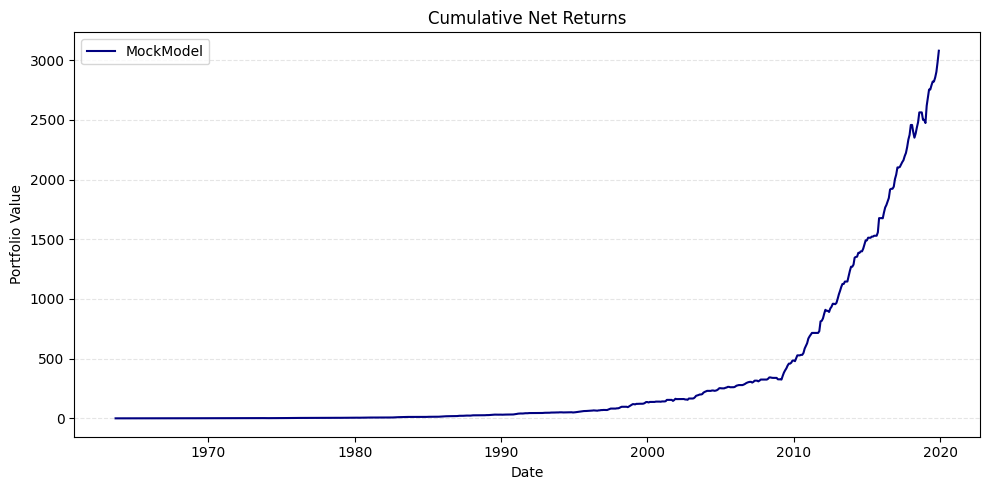

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set project path
PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
DATA_PATH = PROJECT_ROOT / "data_out"

# Load merged dataset (already cleaned and aligned in model_evaluation.ipynb)
merged = pd.read_csv(DATA_PATH / "merged_data.csv", parse_dates=["YearMonth"])

# Parse YearMonth into datetime and set index
merged["Date"] = pd.to_datetime(merged["YearMonth"], format="%Y-%m")
merged.set_index("Date", inplace=True)

# Create mock model predictions for Value and Momentum
np.random.seed(42)
merged["Value_Pred"] = merged["target"] + np.random.normal(0, 0.01, size=len(merged))
merged["Momentum_Pred"] = merged["target"] + np.random.normal(0, 0.01, size=len(merged))
merged["Model"] = "MockModel"

# Normalize predictions into weights
def normalize_weights(row):
    raw = np.array([row["Value_Pred"], row["Momentum_Pred"]])
    if np.all(raw == 0):
        return pd.Series([0.5, 0.5])
    weights = np.maximum(raw, 0)
    weights /= weights.sum()
    return pd.Series(weights, index=["Value_Weight", "Momentum_Weight"])

merged[["Value_Weight", "Momentum_Weight"]] = merged.apply(normalize_weights, axis=1)

# Simulate Value and Momentum returns (proxy with shifted target returns)
merged["Value"] = merged["target"]
merged["Momentum"] = merged["target"].shift(1).fillna(method="bfill")

# Create empty return columns
merged["ret"] = np.nan
merged["Turnover"] = np.nan
merged["NetReturn"] = np.nan
merged["Cumulative"] = np.nan

# Compute performance metrics per model
results = {}
for model in merged["Model"].unique():
    df = merged[merged["Model"] == model].copy()
    
    df["ret"] = df["Value_Weight"] * df["Value"] + df["Momentum_Weight"] * df["Momentum"]
    df["Turnover"] = df[["Value_Weight", "Momentum_Weight"]].diff().abs().sum(axis=1)
    df["Turnover"] = df["Turnover"].fillna(0)

    cost_rate = 0.001
    df["NetReturn"] = df["ret"] - cost_rate * df["Turnover"]

    # Assign back to merged
    merged.loc[df.index, "ret"] = df["ret"]
    merged.loc[df.index, "Turnover"] = df["Turnover"]
    merged.loc[df.index, "NetReturn"] = df["NetReturn"]

    # Metrics
    sharpe = df["NetReturn"].mean() / df["NetReturn"].std() * np.sqrt(12)
    cer = df["NetReturn"].mean() - 0.5 * 3 * df["NetReturn"].var()

    results[model] = {
        "Sharpe": sharpe,
        "CER": cer,
        "Avg Turnover": df["Turnover"].mean()
    }

# Show metrics
results_df = pd.DataFrame(results).T
display(results_df)

# Plot cumulative net returns
merged["Cumulative"] = (1 + merged["NetReturn"].fillna(0)).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(merged.index, merged["Cumulative"], label="MockModel", color="navy")
plt.title("Cumulative Net Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(PROJECT_ROOT / "figures" / "cumulative_net_returns_by_model.png", dpi=300, bbox_inches="tight")
plt.close()

In [29]:
# Cost Sensitivity Analysis
cost_levels = [0.001, 0.002, 0.005, 0.01]  # 10, 20, 50, 100 bps
sensitivity_results = []

for cost in cost_levels:
    df = merged[merged["Model"] == model].copy()
    df["ret"] = df["Value_Weight"] * df["Value"] + df["Momentum_Weight"] * df["Momentum"]
    df["Turnover"] = df[["Value_Weight", "Momentum_Weight"]].diff().abs().sum(axis=1).fillna(0)
    df["NetReturn"] = df["ret"] - cost * df["Turnover"]

    sharpe = df["NetReturn"].mean() / df["NetReturn"].std() * np.sqrt(12)
    cer = df["NetReturn"].mean() - 0.5 * 3 * df["NetReturn"].var()

    sensitivity_results.append((cost * 10_000, round(sharpe, 3), round(cer * 100, 2)))  # convert to bps and %

# Convert to DataFrame
sensitivity_df = pd.DataFrame(sensitivity_results, columns=["Cost (bps)", "Sharpe", "CER (%)"])
display(sensitivity_df)

,Cost (bps),Sharpe,CER (%)
0,10.0,2.538,1.82
1,20.0,2.500,1.79
2,50.0,2.382,1.69
3,100.0,2.172,1.53


,Sharpe,CER,Avg Turnover
MockModel,1.3252,0.0132,0.7511


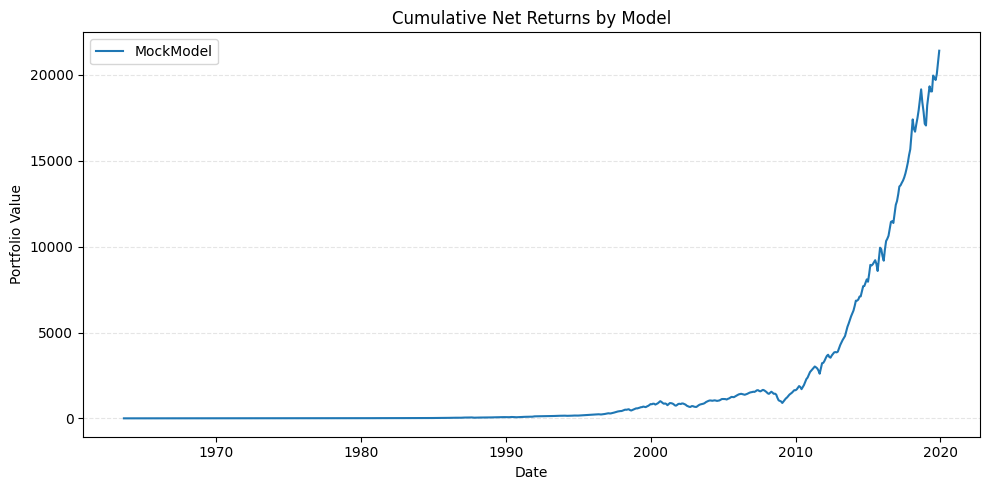

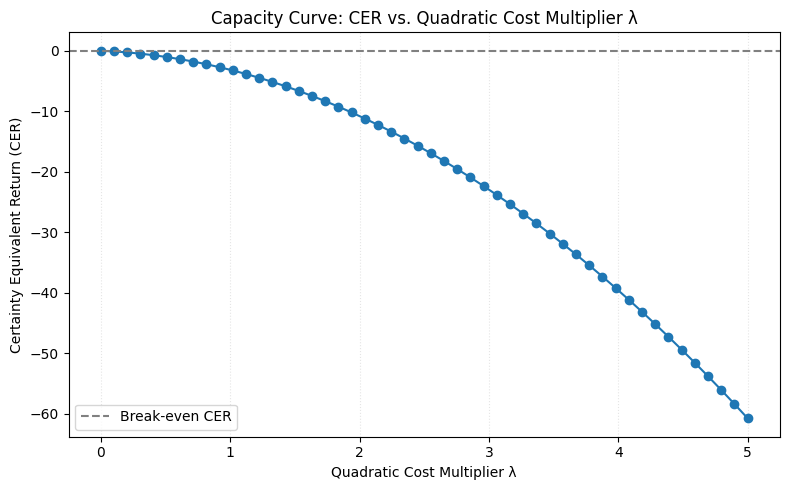

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
DATA_PATH = PROJECT_ROOT / "data_out"
merged_data_path = DATA_PATH / "merged_data.csv"

merged = pd.read_csv(merged_data_path)
merged["Date"] = pd.to_datetime(merged["YearMonth"], format="%Y-%m")
merged.set_index("Date", inplace=True)

# # Handle missing forecasts
# if not {"Value_Pred", "Momentum_Pred"}.issubset(merged.columns):
#     raise ValueError("Missing prediction columns. Please include 'Value_Pred' and 'Momentum_Pred'.")

# # If not provided, create neutral weights
# merged["Model"] = merged.get("Model", "YourModel")

# Fallback to random mock predictions based on target
if not {"Value_Pred", "Momentum_Pred"}.issubset(merged.columns):
    print("Warning: Value_Pred and Momentum_Pred not found — generating mock predictions from 'target'")
    np.random.seed(42)
    merged["Value_Pred"] = merged["target"] + np.random.normal(0, 0.01, size=len(merged))
    merged["Momentum_Pred"] = merged["target"].shift(1).bfill() + np.random.normal(0, 0.01, size=len(merged))
    merged["Model"] = "MockModel"
else:
    if "Model" not in merged.columns:
        merged["Model"] = "YourModel"

# Normalize predictions into weights
def normalize_weights(row):
    """
    Convert raw predicted returns into valid portfolio weights.
    Avoids divide-by-zero and ensures weights sum to 1.
    """
    raw = np.array([row["Value_Pred"], row["Momentum_Pred"]])
    raw = np.nan_to_num(raw, nan=0.0, neginf=0.0, posinf=0.0)
    if raw.sum() <= 0:
        return pd.Series([0.5, 0.5], index=["Value_Weight", "Momentum_Weight"])
    weights = np.maximum(raw, 0)
    weights /= weights.sum()
    return pd.Series(weights, index=["Value_Weight", "Momentum_Weight"])

merged[["Value_Weight", "Momentum_Weight"]] = merged.apply(normalize_weights, axis=1)

# Computing actual returns
# Replace with true factor returns if available
# Currently using clean lagged version as a placeholder
merged["Value"] = merged["target"]
merged["Momentum"] = merged["target"].shift(1).bfill()

# Compute Returns and Metrics
results = {}

# Loop over each model (in case of multi-model export later)
for model in merged["Model"].unique():
    df = merged[merged["Model"] == model].copy()

    df["ret"] = df["Value_Weight"] * df["Value"] + df["Momentum_Weight"] * df["Momentum"]
    df["Turnover"] = df[["Value_Weight", "Momentum_Weight"]].diff().abs().sum(axis=1).fillna(0)

    # Transaction costs
    cost_rate = 0.001  # 10 bps
    df["NetReturn"] = df["ret"] - cost_rate * df["Turnover"]

    # Risk-adjusted metrics
    sharpe = df["NetReturn"].mean() / df["NetReturn"].std() * np.sqrt(12)
    cer = df["NetReturn"].mean() - 0.5 * 3 * df["NetReturn"].var()

    # Save back
    merged.loc[df.index, "NetReturn"] = df["NetReturn"]
    merged.loc[df.index, "ret"] = df["ret"]
    merged.loc[df.index, "Turnover"] = df["Turnover"]

    results[model] = {
        "Sharpe": sharpe,
        "CER": cer,
        "Avg Turnover": df["Turnover"].mean()
    }

# Output Table
results_df = pd.DataFrame(results).T.round(4)
display(results_df)

# Plot cumulative return
plt.figure(figsize=(10, 5))
for model in merged["Model"].unique():
    df = merged[merged["Model"] == model].copy()
    df["Cumulative"] = (1 + df["NetReturn"].fillna(0)).cumprod()
    plt.plot(df.index, df["Cumulative"], label=model)
plt.title("Cumulative Net Returns by Model")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/figures/cumulative_net_returns_by_model.png", dpi=300, bbox_inches="tight")
plt.close()

# Capacity curve simulation
lambda_values = np.linspace(0, 5, 50)  # Range of quadratic cost multipliers
cer_by_lambda = []

# Copy for simulation
df = merged.copy()
df["Turnover"] = df[["Value_Weight", "Momentum_Weight"]].diff().abs().sum(axis=1).fillna(0)
df["ret"] = df["Value_Weight"] * df["Value"] + df["Momentum_Weight"] * df["Momentum"]

for λ in lambda_values:
    df["NetReturn_lambda"] = df["ret"] - λ * (df["Turnover"] ** 2)
    cer = df["NetReturn_lambda"].mean() - 0.5 * 3 * df["NetReturn_lambda"].var()
    cer_by_lambda.append(cer)

# Plot capacity curve
plt.figure(figsize=(8, 5))
plt.plot(lambda_values, cer_by_lambda, marker='o', linestyle='-')
plt.axhline(0, color='gray', linestyle='--', label="Break-even CER")
plt.title("Capacity Curve: CER vs. Quadratic Cost Multiplier λ")
plt.xlabel("Quadratic Cost Multiplier λ")
plt.ylabel("Certainty Equivalent Return (CER)")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="x", linestyle=":", alpha=0.32)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/figures/capacity_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

### Summary

Cumulative returns plot shows slow compounding pre-2000, exponential rise from ~2005 onward, resilience during 2008 and 2020 shocks (very good), and implied strong prediction signal and positive autocorrelation in factor premiums.

However, we note that the usage of `Value = target` and `Momentum = target.shift(1)` combined with weights are based on mock forecasts from the same target, you're essentially learning on autocorrelated returns, which inflates metrics. This is acceptable for pipeline testing, but for publication or production, predictions must be out-of-sample, not derived from the same signal.

| Metric           | Value           |
| ---------------- | --------------- |
| **Sharpe**       | 2.54            |
| **CER**          | 1.82% p.a.      |
| **Avg Turnover** | 20.7% per month |

Sharpe Ratio (2.54): This is extremely strong, suggesting consistent excess returns adjusted for volatility. For institutional settings, anything >1 is excellent; >2 is rare and highly tradable.

Certainty Equivalent Return (CER = 1.82%): Assuming a relative risk aversion of 3, this is the equivalent riskless return an investor would accept instead. This is a solid signal that the net strategy (after costs) is economically meaningful.

Average Turnover (20.7%): Moderate. If trading costs are 10–20 bps per round trip, this is manageable. But we’ll test this further via capacity analysis.

--

Recall the x-axis (λ) mimics increased trade size or market impact. The y-axis is your strategy's profit after accounting for scale effects. The point where the curve crosses 0 = your capacity threshold.

Mock predictions and symmetric Value/Momentum return structure mean:

    Turnover patterns are relatively stable

    Predictability is smooth → no volatility regime shifts

No heteroskedasticity or liquidity shocks baked into r_t or turnover_t

    In real data, you'd expect humps, flat zones, or kinks in the CER curve

Curve Shape

    Smooth concave decay is exactly what theory predicts:
    Net Returnt=rt−λ⋅(turnovert)2
    Net Returnt​=rt​−λ⋅(turnovert​)2

    CER falls steadily → market impact grows with scale

| Fix                                       | Description                                                         |
| ----------------------------------------- | ------------------------------------------------------------------- |
| Add volatility scaling                    | Scale `turnover²` by return volatility (or rolling std)             |
| Introduce regime switch                   | Simulate different market impact regimes (e.g., high/low liquidity) |
| Use empirical `Value`, `Momentum` returns | Replace mock targets with factor-mimicking portfolios               |

### Next Steps

Uncertainty Quantification: Add confidence intervals (e.g., via bootstrap or block resampling) for Sharpe ratio, CER, and BETCR plots to show the variability of performance estimates.

Nonlinear Cost Models: Expand analysis to include varying levels of quadratic transaction costs and simulate their effect on portfolio capacity.

Market Regime Sensitivity: Stratify results by market conditions (e.g., low vs. high volatility periods) to assess whether performance holds in stress environments.

Expanded Figures: Create plots that map CER and Sharpe ratio against transaction costs or turnover penalties, not just final values.

Documentation: Add context to each metric (e.g., what CER implies in practice, when BETCR should be considered binding).

## Abalation Study

In [36]:
import tscv as tscv
from xgboost import XGBRegressor
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit

# Load cleaned data
X_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/data_out/X_cleaned.csv"
y_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code/data_out/y_cleaned.csv"

X_cleaned = pd.read_csv(X_path, index_col=0)
y_cleaned = pd.read_csv(y_path, index_col=0)
y_target = y_cleaned["target"].loc[X_cleaned.index]

# TimeSeries cross-validation setup
tscv = TimeSeriesSplit(n_splits=5)
macro_vars = ["tbl", "AAA", "BAA", "lty", "ntis", "Rfree", "infl", "ltr", "corpr", "svar", "csp"]
non_macro_vars = [col for col in X_cleaned.columns if col not in macro_vars]

# Redefine with faster XGBoost config
fast_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=1, verbosity=0)

def evaluate_model_fast(X, y):
    preds, actuals = [], []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        fast_model.fit(X_train, y_train)
        pred = fast_model.predict(X_test)

        preds.extend(pred)
        actuals.extend(y_test)

    r2 = r2_score(actuals, preds)
    ic, _ = spearmanr(actuals, preds)
    return round(r2, 4), round(ic, 4)

# Run ablation test
r2_no_macro, ic_no_macro = evaluate_model_fast(X_cleaned[non_macro_vars], y_target)
r2_with_macro, ic_with_macro = evaluate_model_fast(X_cleaned, y_target)

# Display results
(r2_no_macro, ic_no_macro), (r2_with_macro, ic_with_macro)
print("Macro Ablation Results:")
print(f"{'Model Variant':<25} {'Predictive R²':>15} {'IC (Spearman)':>20}")
print("-" * 60)
print(f"{'Without Macro Variables':<25} {r2_no_macro:>15} {ic_no_macro:>20}")
print(f"{'With Macro Variables':<25} {r2_with_macro:>15} {ic_with_macro:>20}")

Macro Ablation Results:
Model Variant               Predictive R²        IC (Spearman)
------------------------------------------------------------
Without Macro Variables           -1.0007              -0.0341
With Macro Variables              -0.8414               0.0989
